## 1. Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold

sns.set_theme(style="whitegrid")
np.set_printoptions(precision=4, suppress=True)

## 2. Подготовка данных

In [ ]:
def standardize_fit(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std = np.where(std == 0, 1.0, std)
    return mean, std

def standardize_transform(X, mean, std):
    return (X - mean) / std

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=96
)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=96
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=96
)

mean, std = standardize_fit(X_train)
X_train_std = standardize_transform(X_train, mean, std)
X_val_std = standardize_transform(X_val, mean, std)
X_test_std = standardize_transform(X_test, mean, std)
X_train_full_std = standardize_transform(X_train_full, mean, std)

print("Train:", X_train_std.shape, y_train.shape)
print("Val:", X_val_std.shape, y_val.shape)
print("Test:", X_test_std.shape, y_test.shape)

Train: (280, 2) (280,)
Val: (70, 2) (70,)
Test: (150, 2) (150,)


Стандартизация выполняется только по обучающей выборке.

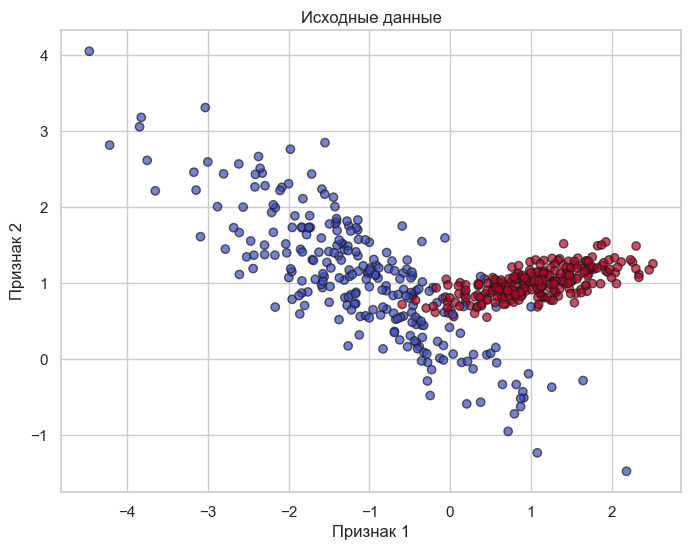

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.title("Исходные данные")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.show()

## 3. Реализация однослойного перцептрона

In [11]:
class SingleLayerPerceptron:
    def __init__(
        self,
        input_dim,
        init_mode="small_random",
        random_state=42,
        loss_type="bce",
        l2_lambda=0.0,
        momentum_beta=0.0
    ):
        self.input_dim = input_dim
        self.init_mode = init_mode
        self.random_state = random_state
        self.loss_type = loss_type
        self.l2_lambda = l2_lambda
        self.momentum_beta = momentum_beta

        self.w = None
        self.b = None

        self.train_loss_history = []
        self.val_loss_history = []

        self._init_params()

    def _init_params(self):
        rng = np.random.default_rng(self.random_state)

        if self.init_mode == "zeros":
            self.w = np.zeros(self.input_dim)
        elif self.init_mode == "small_random":
            self.w = rng.normal(0, 0.01, size=self.input_dim)
        elif self.init_mode == "large_random":
            self.w = rng.normal(0, 10, size=self.input_dim)
        else:
            raise ValueError("Unknown init_mode")

        self.b = 0.0

    @staticmethod
    def sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def forward(self, X):
        z = X @ self.w + self.b
        return self.sigmoid(z)

    def decision_function(self, X):
        return X @ self.w + self.b

    def compute_loss(self, y_true, y_pred):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)

        if self.loss_type == "bce":
            bce = -np.mean(
                y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
            )
            l2_term = 0.5 * self.l2_lambda * np.sum(self.w ** 2)
            return bce + l2_term

        elif self.loss_type == "hinge":
            margins = 1 - y_true * y_pred
            hinge = np.mean(np.maximum(0, margins))
            l2_term = 0.5 * self.l2_lambda * np.sum(self.w ** 2)
            return hinge + l2_term

        else:
            raise ValueError("Unknown loss_type")

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba >= 0.5).astype(int)

    def fit(self, X_train, y_train, X_val=None, y_val=None, epochs=100, lr=0.1, batch_size=32):
        n_samples = X_train.shape[0]
        rng = np.random.default_rng(self.random_state)

        self.train_loss_history = []
        self.val_loss_history = []

        v_w = np.zeros_like(self.w)
        v_b = 0.0

        for epoch in range(epochs):
            indices = rng.permutation(n_samples)
            X_train_shuffled = X_train[indices]
            y_train_shuffled = y_train[indices]

            for start in range(0, n_samples, batch_size):
                end = start + batch_size
                X_batch = X_train_shuffled[start:end]
                y_batch = y_train_shuffled[start:end]

                if self.loss_type == "bce":
                    y_pred = self.forward(X_batch)
                    error = y_pred - y_batch

                    grad_w = (X_batch.T @ error) / len(X_batch)
                    grad_b = np.mean(error)

                elif self.loss_type == "hinge":
                    y_batch_pm1 = 2 * y_batch - 1
                    scores = self.decision_function(X_batch)
                    margins = 1 - y_batch_pm1 * scores
                    active = margins > 0

                    if np.any(active):
                        grad_w = -np.mean((y_batch_pm1[active, None] * X_batch[active]), axis=0)
                        grad_b = -np.mean(y_batch_pm1[active])
                    else:
                        grad_w = np.zeros_like(self.w)
                        grad_b = 0.0

                grad_w += self.l2_lambda * self.w

                if self.momentum_beta > 0:
                    v_w = self.momentum_beta * v_w + (1 - self.momentum_beta) * grad_w
                    v_b = self.momentum_beta * v_b + (1 - self.momentum_beta) * grad_b
                    self.w -= lr * v_w
                    self.b -= lr * v_b
                else:
                    self.w -= lr * grad_w
                    self.b -= lr * grad_b

            if self.loss_type == "bce":
                train_pred = self.forward(X_train)
                train_loss = self.compute_loss(y_train, train_pred)

                if X_val is not None and y_val is not None:
                    val_pred = self.forward(X_val)
                    val_loss = self.compute_loss(y_val, val_pred)
                else:
                    val_loss = None

            elif self.loss_type == "hinge":
                train_scores = self.decision_function(X_train)
                y_train_pm1 = 2 * y_train - 1
                train_loss = self.compute_loss(y_train_pm1, train_scores)

                if X_val is not None and y_val is not None:
                    val_scores = self.decision_function(X_val)
                    y_val_pm1 = 2 * y_val - 1
                    val_loss = self.compute_loss(y_val_pm1, val_scores)
                else:
                    val_loss = None

            self.train_loss_history.append(train_loss)
            if val_loss is not None:
                self.val_loss_history.append(val_loss)

        return self

## 4. Дополнительные функции для оценки качества и визуализации

In [12]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_binary(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

def precision_score_binary(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix_binary(y_true, y_pred)
    return tp / (tp + fp + 1e-15)

def recall_score_binary(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix_binary(y_true, y_pred)
    return tp / (tp + fn + 1e-15)

def f1_score_binary(y_true, y_pred):
    precision = precision_score_binary(y_true, y_pred)
    recall = recall_score_binary(y_true, y_pred)
    return 2 * precision * recall / (precision + recall + 1e-15)

def roc_curve_manual(y_true, y_scores):
    thresholds = np.sort(np.unique(y_scores))[::-1]
    thresholds = np.concatenate(([1.0 + 1e-6], thresholds, [-1e-6]))

    tpr_list = []
    fpr_list = []

    for thr in thresholds:
        y_pred = (y_scores >= thr).astype(int)
        tp, tn, fp, fn = confusion_matrix_binary(y_true, y_pred)

        tpr = tp / (tp + fn + 1e-15)
        fpr = fp / (fp + tn + 1e-15)

        tpr_list.append(tpr)
        fpr_list.append(fpr)

    return np.array(fpr_list), np.array(tpr_list), thresholds

def auc_trapezoid(x, y):
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    return np.trapezoid(y, x)

def plot_loss_curves(train_loss, val_loss=None, title="График loss"):
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label="Train loss", linewidth=2)
    if val_loss is not None and len(val_loss) > 0:
        plt.plot(val_loss, label="Val loss", linewidth=2)
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_decision_boundary(model, X, y, title="Разделяющая граница"):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, probs, levels=30, cmap="coolwarm", alpha=0.25)
    plt.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.8)
    plt.title(title)
    plt.xlabel("Признак 1 (стандартизованный)")
    plt.ylabel("Признак 2 (стандартизованный)")
    plt.show()

def plot_roc_curve(y_true, y_scores, title="ROC-кривая"):
    fpr, tpr, _ = roc_curve_manual(y_true, y_scores)
    roc_auc = auc_trapezoid(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

    return roc_auc

## 5. Базовое обучение модели

In [13]:
model = SingleLayerPerceptron(
    input_dim=2,
    init_mode="small_random",
    random_state=42,
    loss_type="bce"
)

model.fit(
    X_train_std, y_train,
    X_val=X_val_std, y_val=y_val,
    epochs=100,
    lr=0.1,
    batch_size=32
)

y_train_pred = model.predict(X_train_std)
y_test_pred = model.predict(X_test_std)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print("Весы w:", model.w)
print("Смещение b:", model.b)

Train accuracy: 0.9464
Test accuracy:  0.9333
Весы w: [4.3917 1.2586]
Смещение b: 0.15338158686775505


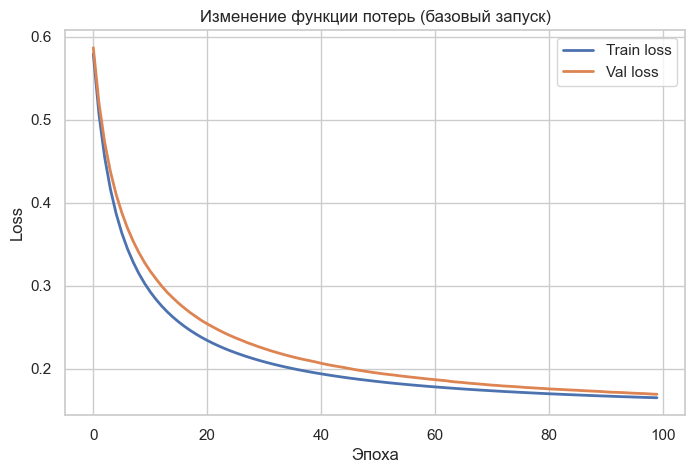

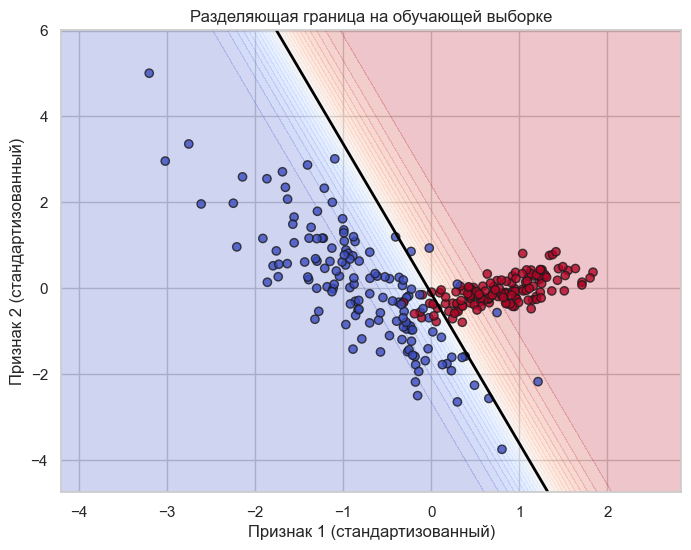

In [14]:
plot_loss_curves(
    model.train_loss_history,
    model.val_loss_history,
    title="Изменение функции потерь (базовый запуск)"
)

plot_decision_boundary(
    model,
    X_train_std,
    y_train,
    title="Разделяющая граница на обучающей выборке"
)

## 6. Универсальная функция для запуска экспериментов

In [15]:
def run_single_experiment(
    X_train, y_train, X_val, y_val, X_test, y_test,
    epochs=100, lr=0.1, batch_size=32,
    init_mode="small_random",
    loss_type="bce",
    l2_lambda=0.0,
    momentum_beta=0.0,
    random_state=42
):
    model = SingleLayerPerceptron(
        input_dim=X_train.shape[1],
        init_mode=init_mode,
        random_state=random_state,
        loss_type=loss_type,
        l2_lambda=l2_lambda,
        momentum_beta=momentum_beta
    )

    model.fit(
        X_train, y_train,
        X_val=X_val, y_val=y_val,
        epochs=epochs,
        lr=lr,
        batch_size=batch_size
    )

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    result = {
        "model": model,
        "train_acc": accuracy_score(y_train, y_train_pred),
        "val_acc": accuracy_score(y_val, y_val_pred),
        "test_acc": accuracy_score(y_test, y_test_pred),
        "final_train_loss": model.train_loss_history[-1],
        "final_val_loss": model.val_loss_history[-1] if len(model.val_loss_history) > 0 else None
    }
    return result

## 7. Эксперимент 1: влияние скорости обучения

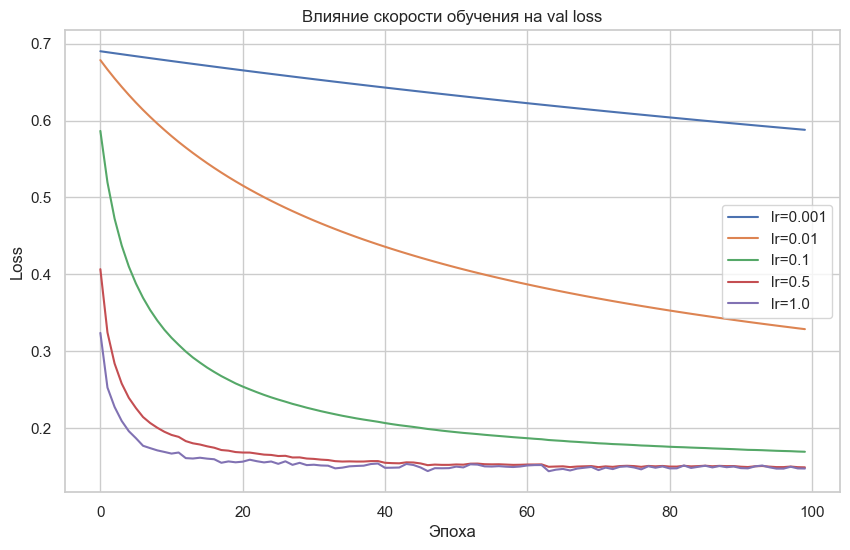

Результаты по learning rate:
lr=0.001 | train_acc=0.9143 | val_acc=0.8857 | test_acc=0.9067 | val_loss=0.5879
lr=0.01  | train_acc=0.9286 | val_acc=0.9143 | test_acc=0.9067 | val_loss=0.3287
lr=0.1   | train_acc=0.9464 | val_acc=0.9286 | test_acc=0.9333 | val_loss=0.1692
lr=0.5   | train_acc=0.9429 | val_acc=0.9571 | test_acc=0.9333 | val_loss=0.1489
lr=1.0   | train_acc=0.9429 | val_acc=0.9571 | test_acc=0.9333 | val_loss=0.1474


In [16]:
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
lr_results = []

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    result = run_single_experiment(
        X_train_std, y_train,
        X_val_std, y_val,
        X_test_std, y_test,
        epochs=100,
        lr=lr,
        batch_size=32,
        init_mode="small_random",
        random_state=42
    )
    lr_results.append((lr, result))
    plt.plot(result["model"].val_loss_history, label=f"lr={lr}")

plt.title("Влияние скорости обучения на val loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.show()

print("Результаты по learning rate:")
for lr, result in lr_results:
    print(
        f"lr={lr:<5} | "
        f"train_acc={result['train_acc']:.4f} | "
        f"val_acc={result['val_acc']:.4f} | "
        f"test_acc={result['test_acc']:.4f} | "
        f"val_loss={result['final_val_loss']:.4f}"
    )

## 8. Эксперимент 2: влияние размера батча

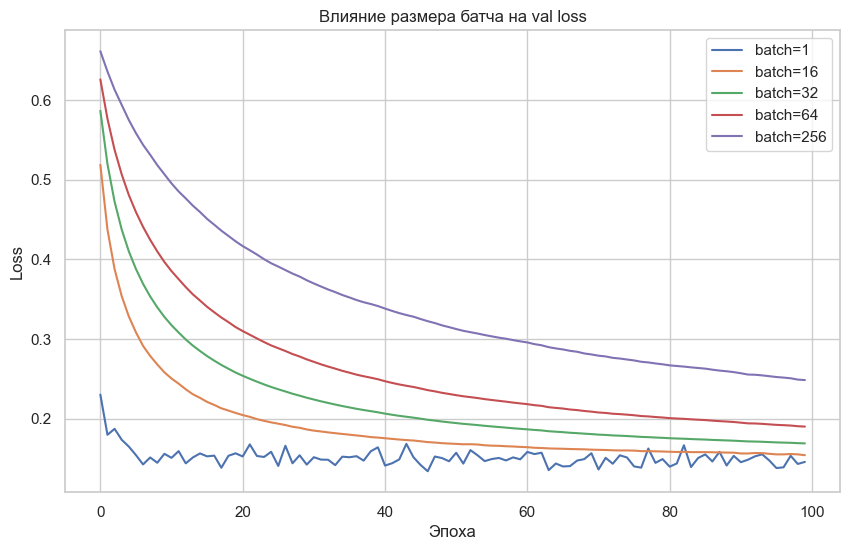

Результаты по batch_size:
batch=1   | train_acc=0.9429 | val_acc=0.9571 | test_acc=0.9400 | val_loss=0.1460
batch=16  | train_acc=0.9429 | val_acc=0.9429 | test_acc=0.9400 | val_loss=0.1544
batch=32  | train_acc=0.9464 | val_acc=0.9286 | test_acc=0.9333 | val_loss=0.1692
batch=64  | train_acc=0.9429 | val_acc=0.9143 | test_acc=0.9333 | val_loss=0.1903
batch=256 | train_acc=0.9393 | val_acc=0.9000 | test_acc=0.9200 | val_loss=0.2486


In [17]:
batch_sizes = [1, 16, 32, 64, 256]
batch_results = []

plt.figure(figsize=(10, 6))

for batch_size in batch_sizes:
    result = run_single_experiment(
        X_train_std, y_train,
        X_val_std, y_val,
        X_test_std, y_test,
        epochs=100,
        lr=0.1,
        batch_size=batch_size,
        init_mode="small_random",
        random_state=42
    )
    batch_results.append((batch_size, result))
    plt.plot(result["model"].val_loss_history, label=f"batch={batch_size}")

plt.title("Влияние размера батча на val loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.show()

print("Результаты по batch_size:")
for batch_size, result in batch_results:
    print(
        f"batch={batch_size:<3} | "
        f"train_acc={result['train_acc']:.4f} | "
        f"val_acc={result['val_acc']:.4f} | "
        f"test_acc={result['test_acc']:.4f} | "
        f"val_loss={result['final_val_loss']:.4f}"
    )

## 9. Эксперимент 3: влияние инициализации весов

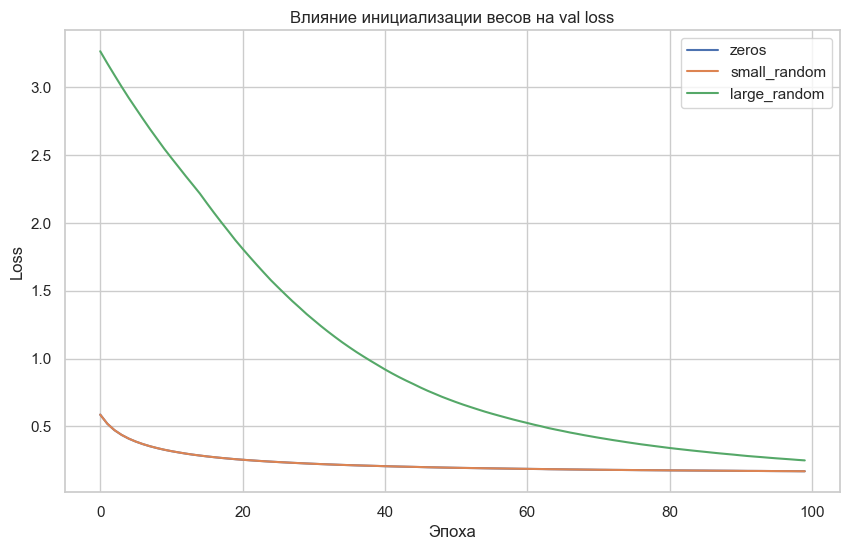

Результаты по инициализации:
init=zeros        | train_acc=0.9464 | val_acc=0.9286 | test_acc=0.9333 | val_loss=0.1692
init=small_random | train_acc=0.9464 | val_acc=0.9286 | test_acc=0.9333 | val_loss=0.1692
init=large_random | train_acc=0.9250 | val_acc=0.9000 | test_acc=0.9133 | val_loss=0.2493


In [18]:
init_modes = ["zeros", "small_random", "large_random"]
init_results = []

plt.figure(figsize=(10, 6))

for init_mode in init_modes:
    result = run_single_experiment(
        X_train_std, y_train,
        X_val_std, y_val,
        X_test_std, y_test,
        epochs=100,
        lr=0.1,
        batch_size=32,
        init_mode=init_mode,
        random_state=42
    )
    init_results.append((init_mode, result))
    plt.plot(result["model"].val_loss_history, label=init_mode)

plt.title("Влияние инициализации весов на val loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.show()

print("Результаты по инициализации:")
for init_mode, result in init_results:
    print(
        f"init={init_mode:<12} | "
        f"train_acc={result['train_acc']:.4f} | "
        f"val_acc={result['val_acc']:.4f} | "
        f"test_acc={result['test_acc']:.4f} | "
        f"val_loss={result['final_val_loss']:.4f}"
    )

## 10. Дополнительное задание 1: собственный генератор данных

In [19]:
def generate_gaussian_blobs(n_samples=400, mean1=(-2, -2), mean2=(2, 2),
                            cov1=None, cov2=None, noise_prob=0.0, random_state=42):
    rng = np.random.default_rng(random_state)

    if cov1 is None:
        cov1 = np.array([[1.0, 0.2], [0.2, 1.0]])
    if cov2 is None:
        cov2 = np.array([[1.0, -0.2], [-0.2, 1.0]])

    n1 = n_samples // 2
    n2 = n_samples - n1

    X1 = rng.multivariate_normal(mean1, cov1, size=n1)
    X2 = rng.multivariate_normal(mean2, cov2, size=n2)

    X = np.vstack([X1, X2])
    y = np.hstack([np.zeros(n1, dtype=int), np.ones(n2, dtype=int)])

    flips = rng.random(len(y)) < noise_prob
    y[flips] = 1 - y[flips]

    return X, y

def generate_xor(n_samples=400, noise=0.2, label_noise=0.0, random_state=42):
    rng = np.random.default_rng(random_state)
    X = rng.uniform(-1, 1, size=(n_samples, 2))
    y = ((X[:, 0] > 0) ^ (X[:, 1] > 0)).astype(int)

    X += rng.normal(0, noise, size=X.shape)

    flips = rng.random(n_samples) < label_noise
    y[flips] = 1 - y[flips]

    return X, y

def generate_circles(n_samples=400, radius=0.8, noise=0.1, label_noise=0.0, random_state=42):
    rng = np.random.default_rng(random_state)
    X = rng.uniform(-1.5, 1.5, size=(n_samples, 2))
    r = np.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2)
    y = (r > radius).astype(int)

    X += rng.normal(0, noise, size=X.shape)

    flips = rng.random(n_samples) < label_noise
    y[flips] = 1 - y[flips]

    return X, y

XOR test accuracy: 0.36666666666666664


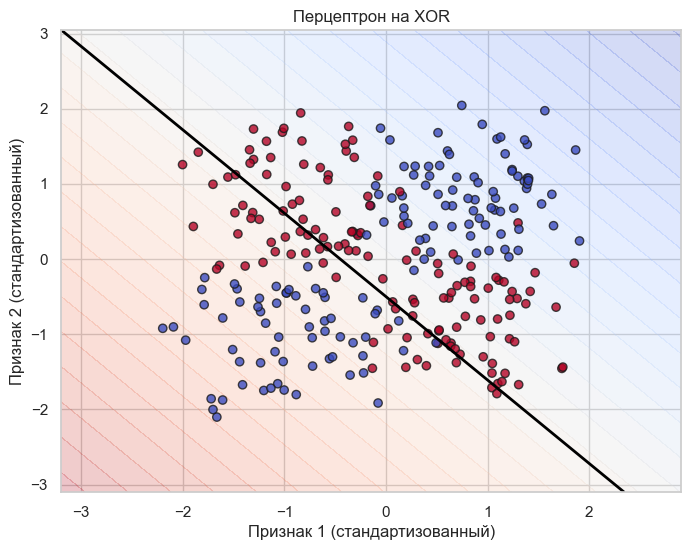

In [34]:
X_custom, y_custom = generate_xor(n_samples=500, noise=0.15, label_noise=0.0, random_state=42)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_custom, y_custom, test_size=0.3, stratify=y_custom, random_state=42
)
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_train_c, y_train_c, test_size=0.2, stratify=y_train_c, random_state=42
)

mean_c, std_c = standardize_fit(X_train_c)
X_train_c = standardize_transform(X_train_c, mean_c, std_c)
X_val_c = standardize_transform(X_val_c, mean_c, std_c)
X_test_c = standardize_transform(X_test_c, mean_c, std_c)

model_xor = SingleLayerPerceptron(input_dim=2, random_state=42)
model_xor.fit(X_train_c, y_train_c, X_val_c, y_val_c, epochs=100, lr=0.1, batch_size=32)

print("XOR test accuracy:", accuracy_score(y_test_c, model_xor.predict(X_test_c)))
plot_decision_boundary(model_xor, X_train_c, y_train_c, title="Перцептрон на XOR")

## 11. Дополнительное задание 2: hinge loss и L2-регуляризация

Hinge train accuracy: 0.9464285714285714
Hinge test accuracy: 0.9333333333333333


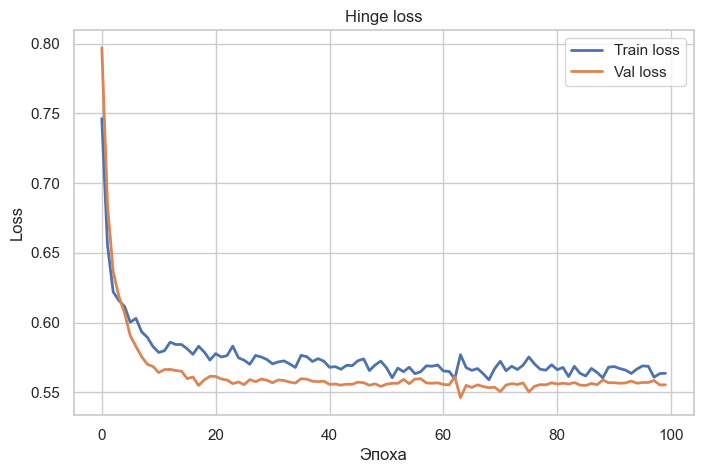

In [20]:
hinge_model = SingleLayerPerceptron(
    input_dim=2,
    init_mode="small_random",
    random_state=42,
    loss_type="hinge"
)

hinge_model.fit(
    X_train_std, y_train,
    X_val_std, y_val,
    epochs=100,
    lr=0.1,
    batch_size=32
)

print("Hinge train accuracy:", accuracy_score(y_train, hinge_model.predict(X_train_std)))
print("Hinge test accuracy:", accuracy_score(y_test, hinge_model.predict(X_test_std)))

plot_loss_curves(
    hinge_model.train_loss_history,
    hinge_model.val_loss_history,
    title="Hinge loss"
)

In [21]:
lambdas = [0.0, 0.001, 0.01, 0.1, 1.0]
l2_results = []

for lam in lambdas:
    result = run_single_experiment(
        X_train_std, y_train,
        X_val_std, y_val,
        X_test_std, y_test,
        epochs=100,
        lr=0.1,
        batch_size=32,
        init_mode="small_random",
        l2_lambda=lam,
        random_state=42
    )
    weight_norm = np.linalg.norm(result["model"].w)
    l2_results.append((lam, result, weight_norm))

print("L2-регуляризация:")
for lam, result, weight_norm in l2_results:
    print(
        f"lambda={lam:<5} | "
        f"||w||={weight_norm:.4f} | "
        f"test_acc={result['test_acc']:.4f} | "
        f"val_loss={result['final_val_loss']:.4f}"
    )

L2-регуляризация:
lambda=0.0   | ||w||=4.5685 | test_acc=0.9333 | val_loss=0.1692
lambda=0.001 | ||w||=4.3996 | test_acc=0.9333 | val_loss=0.1822
lambda=0.01  | ||w||=3.3537 | test_acc=0.9333 | val_loss=0.2608
lambda=0.1   | ||w||=1.4118 | test_acc=0.9133 | val_loss=0.4636
lambda=1.0   | ||w||=0.3107 | test_acc=0.9133 | val_loss=0.6383


## 12. Дополнительное задание 3: метрики качества и анализ ошибок

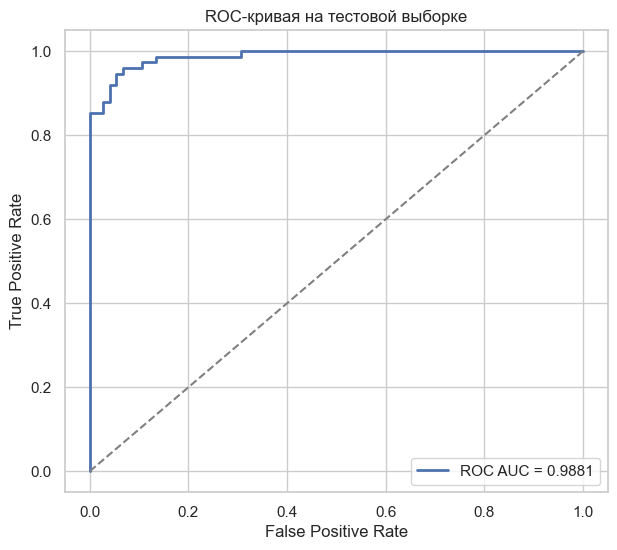

Precision: 0.9114
Recall:    0.9600
F1-score:  0.9351
ROC-AUC:   0.9881


In [22]:
y_test_scores = model.predict_proba(X_test_std)
y_test_pred = model.predict(X_test_std)

precision = precision_score_binary(y_test, y_test_pred)
recall = recall_score_binary(y_test, y_test_pred)
f1 = f1_score_binary(y_test, y_test_pred)
roc_auc = plot_roc_curve(y_test, y_test_scores, title="ROC-кривая на тестовой выборке")

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

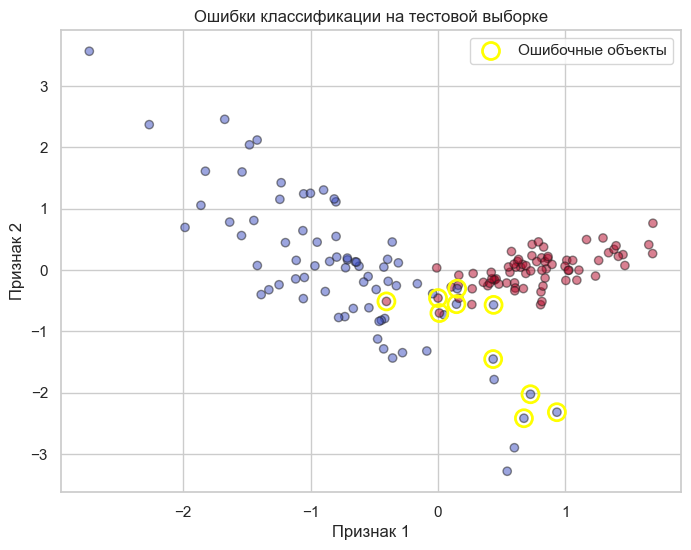

In [23]:
misclassified = y_test_pred != y_test

plt.figure(figsize=(8, 6))
plt.scatter(X_test_std[:, 0], X_test_std[:, 1], c=y_test, cmap="coolwarm", alpha=0.5, edgecolor="k")
plt.scatter(
    X_test_std[misclassified, 0],
    X_test_std[misclassified, 1],
    facecolors="none",
    edgecolors="yellow",
    s=150,
    linewidths=2,
    label="Ошибочные объекты"
)
plt.title("Ошибки классификации на тестовой выборке")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.legend()
plt.show()

## 13. Дополнительное задание 4: исследование сходимости градиентного спуска с momentum

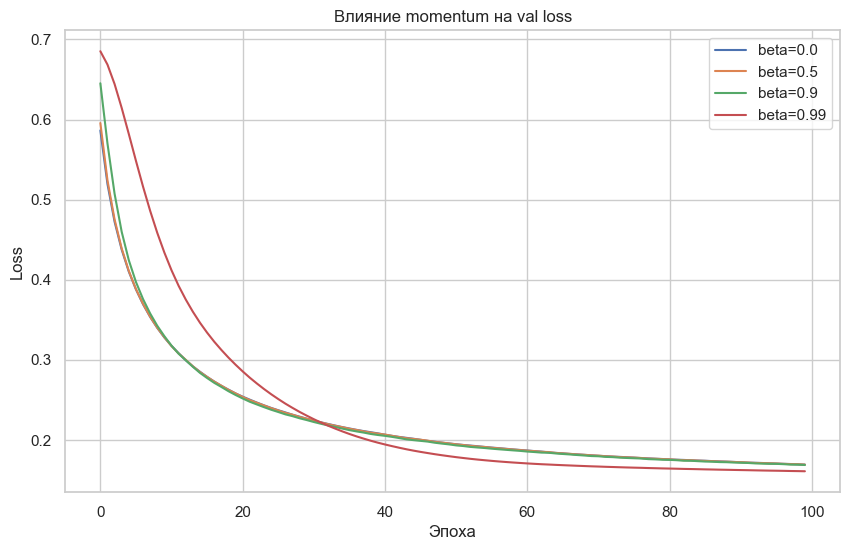

beta=0.0  | train_acc=0.9464 | val_acc=0.9286 | test_acc=0.9333
beta=0.5  | train_acc=0.9464 | val_acc=0.9286 | test_acc=0.9333
beta=0.9  | train_acc=0.9464 | val_acc=0.9286 | test_acc=0.9333
beta=0.99 | train_acc=0.9464 | val_acc=0.9286 | test_acc=0.9333


In [24]:
betas = [0.0, 0.5, 0.9, 0.99]
momentum_results = []

plt.figure(figsize=(10, 6))

for beta in betas:
    result = run_single_experiment(
        X_train_std, y_train,
        X_val_std, y_val,
        X_test_std, y_test,
        epochs=100,
        lr=0.1,
        batch_size=32,
        init_mode="small_random",
        momentum_beta=beta,
        random_state=42
    )
    momentum_results.append((beta, result))
    plt.plot(result["model"].val_loss_history, label=f"beta={beta}")

plt.title("Влияние momentum на val loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.show()

for beta, result in momentum_results:
    print(
        f"beta={beta:<4} | "
        f"train_acc={result['train_acc']:.4f} | "
        f"val_acc={result['val_acc']:.4f} | "
        f"test_acc={result['test_acc']:.4f}"
    )

## 14. Дополнительное задание 5: 5-кратная кросс-валидация и подбор гиперпараметров

In [25]:
def cross_validate_perceptron(X, y, lr_list, batch_size_list, epochs=100, random_state=42):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    results = []

    for lr in lr_list:
        for batch_size in batch_size_list:
            fold_scores = []

            for train_idx, val_idx in skf.split(X, y):
                X_tr, X_va = X[train_idx], X[val_idx]
                y_tr, y_va = y[train_idx], y[val_idx]

                mean, std = standardize_fit(X_tr)
                X_tr = standardize_transform(X_tr, mean, std)
                X_va = standardize_transform(X_va, mean, std)

                model = SingleLayerPerceptron(
                    input_dim=X.shape[1],
                    init_mode="small_random",
                    random_state=random_state
                )

                model.fit(
                    X_tr, y_tr,
                    X_val=X_va, y_val=y_va,
                    epochs=epochs,
                    lr=lr,
                    batch_size=batch_size
                )

                y_va_pred = model.predict(X_va)
                fold_scores.append(accuracy_score(y_va, y_va_pred))

            results.append({
                "lr": lr,
                "batch_size": batch_size,
                "mean_acc": np.mean(fold_scores),
                "std_acc": np.std(fold_scores)
            })

    return results

In [26]:
cv_results = cross_validate_perceptron(
    X_train_full, y_train_full,
    lr_list=[0.001, 0.01, 0.1, 0.5],
    batch_size_list=[1, 16, 32, 64, 256],
    epochs=100
)

sorted_results = sorted(cv_results, key=lambda x: x["mean_acc"], reverse=True)

print(f"{'№':<3} {'lr':<8} {'batch_size':<12} {'mean_acc':<12} {'std_acc':<12}")
print("-" * 55)

for i, row in enumerate(sorted_results, start=1):
    print(
        f"{i:<3} "
        f"{row['lr']:<8} "
        f"{row['batch_size']:<12} "
        f"{row['mean_acc']:<12.4f} "
        f"{row['std_acc']:<12.4f}"
    )

best = sorted_results[0]
print("\nЛучшая комбинация гиперпараметров:")
print(f"lr = {best['lr']}, batch_size = {best['batch_size']}")
print(f"Средняя accuracy = {best['mean_acc']:.4f}")
print(f"Стандартное отклонение = {best['std_acc']:.4f}")

№   lr       batch_size   mean_acc     std_acc     
-------------------------------------------------------
1   0.1      64           0.9457       0.0229      
2   0.1      32           0.9429       0.0221      
3   0.5      1            0.9429       0.0239      
4   0.01     1            0.9400       0.0210      
5   0.1      1            0.9400       0.0210      
6   0.1      16           0.9400       0.0210      
7   0.5      16           0.9400       0.0210      
8   0.5      32           0.9400       0.0210      
9   0.5      64           0.9400       0.0210      
10  0.5      256          0.9400       0.0210      
11  0.001    1            0.9314       0.0318      
12  0.01     16           0.9257       0.0291      
13  0.1      256          0.9257       0.0291      
14  0.01     32           0.9171       0.0355      
15  0.01     64           0.9143       0.0373      
16  0.001    16           0.9029       0.0455      
17  0.001    64           0.9000       0.0592      
18  0.01